In [28]:
# Predict Hurricane size using Random Forest

import numpy as np
import pandas as pd
import re, math, os, warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import joblib

import matplotlib.pyplot as plt
import seaborn as sns


read_csv = pd.read_csv("Hurricane_dataset - Sheet1.csv")
df = pd.DataFrame(read_csv)
df.head()


,num,Date,Time,Lat,Long,Max_Winds_kt,SSHWS,RMW_nm,Central_Pressure,OCI_mb,Size_nm,States_Affected,Strom_Name,Unnamed: 13,Unnamed: 14
0,1,7/11/1901,0700Z,36.0N,75.8W,70,1,---,-983,1013,175,NC1,---------------,NaN,NaN
1,2,8/14/1901,2100Z,29.3N,89.6W,75,1,---,-973,1010,300,LA1,---------------,NaN,NaN
2,3,8/15/1901,1700Z,30.4N,88.8W,75,1,35,973,1010,300,"MS1,AL1",---------------,NaN,NaN
3,4,9/11/1903,2300Z,26.1N,80.1W,75,1,45,976,1013,150,CFL1,---------------,NaN,NaN
4,5,9/13/1903,2300Z,30.1N,85.6W,80,1,---,-974,1014,200,AFL1,---------------,NaN,NaN


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   num               170 non-null    int64 
 1   Date              170 non-null    object
 2   Time              170 non-null    object
 3   Lat               170 non-null    object
 4   Long              170 non-null    object
 5   Max_Winds_kt      170 non-null    int64 
 6   SSHWS             170 non-null    int64 
 7   RMW_nm            170 non-null    object
 8   Central_Pressure  170 non-null    int64 
 9   OCI_mb            170 non-null    int64 
 10  Size_nm           170 non-null    int64 
 11  States_Affected   170 non-null    object
 12  Strom_Name        170 non-null    object
 13  Unnamed: 13       16 non-null     object
 14  Unnamed: 14       3 non-null      object
dtypes: int64(6), object(9)
memory usage: 20.1+ KB


In [30]:
# Drop unnamed/junk columns if any
for c in list(df.columns):
    if "Unnamed" in c: # drop any columns that are unnamed
        df.drop(columns=c, inplace=True, errors="ignore")

# Normalize column names
df.columns = [c.strip().replace(" ", "_") for c in df.columns] # repalce the underscores with a space


def parse_lat(x):
    if pd.isna(x): return np.nan # check if input is null and if so return NaN
    s = str(x).strip() # inputs will look like 35.6N and we are converting into a string and removing trailing/leading spaces
    m = re.match(r"^([+-]?\d+(?:\.\d+)?)([NnSs])$", s) # we use a regular expression to see if a string looks like a number followed by N or S ([NnSs]) caputres direction
    if m: # if match exists
        val = float(m.group(1)) # convert the numeric part to a float
        return val if m.group(2).upper()=="N" else -val # convert the float to negative if S or keep pos if N (will help with determingn what is in northern hemisphere and be more compatible with our GIS data)
    try: return float(s)
    except: return np.nan

def parse_lon(x):
    if pd.isna(x): return np.nan
    s = str(x).strip()
    m = re.match(r"^([+-]?\d+(?:\.\d+)?)([EeWw])$", s)
    if m:
        val = float(m.group(1))
        return -val if m.group(2).upper()=="W" else val
    try: return float(s)
    except: return np.nan

def parse_rmw(x):
    if pd.isna(x): return np.nan
    s = str(x).strip()
    if s in {"---","--","-"}: return np.nan
    s = s.replace(",", "")
    try: return float(s)
    except: return np.nan

def parse_pressure(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().replace(",", "")
    m = re.match(r"^\(?\s*(-?\d+(?:\.\d+)?)\s*\)?$", s)  # handles (983) or -983
    if m: return abs(float(m.group(1)))
    try: return abs(float(s))
    except: return np.nan

def parse_time_to_hour(t):
    if pd.isna(t): return np.nan
    s = str(t).strip().upper().replace("Z","")
    m = re.match(r"^(\d{2})(\d{2})$", s)  # 2300 -> 23
    if m: return int(m.group(1))
    try:
        h = int(s)
        return h if 0 <= h <= 23 else np.nan
    except:
        return np.nan



In [31]:
# Parse and clean columns only if they are present in the dataset by calling previous functions
if "Lat" in df.columns: df["Lat"] = df["Lat"].apply(parse_lat)
if "Long" in df.columns: df["Long"] = df["Long"].apply(parse_lon)
if "RMW_nm" in df.columns: df["RMW_nm"] = df["RMW_nm"].apply(parse_rmw)

if "Central_Pressure" in df.columns: df["Central_Pressure"] = df["Central_Pressure"].apply(parse_pressure)
if "OCI_mb" in df.columns: df["OCI_mb"] = pd.to_numeric(df["OCI_mb"], errors="coerce")

# Date & time to numeric parts
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["Year"]  = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Day"]   = df["Date"].dt.day

if "Time" in df.columns:
    df["Hour"] = df["Time"].apply(parse_time_to_hour)

# Simple derived features
if "Lat" in df.columns:
    df["Abs_Lat"] = df["Lat"].abs()
if {"Max_Winds_kt", "Central_Pressure"}.issubset(df.columns):
    df["Wind_to_Pressure"] = df["Max_Winds_kt"] / (df["Central_Pressure"] + 1e-6)

print("After cleaning shape:", df.shape)
df.info()

After cleaning shape: (170, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   num               170 non-null    int64         
 1   Date              151 non-null    datetime64[ns]
 2   Time              170 non-null    object        
 3   Lat               170 non-null    float64       
 4   Long              170 non-null    float64       
 5   Max_Winds_kt      170 non-null    int64         
 6   SSHWS             170 non-null    int64         
 7   RMW_nm            130 non-null    float64       
 8   Central_Pressure  170 non-null    float64       
 9   OCI_mb            170 non-null    int64         
 10  Size_nm           170 non-null    int64         
 11  States_Affected   170 non-null    object        
 12  Strom_Name        170 non-null    object        
 13  Year              151 non-null    float64       

In [32]:
# We know Central Pressure is the one that affects this the most
df = df.drop(['States_Affected', 'Strom_Name', 'Time'], axis=1)


In [34]:
df.head()

,num,Date,Lat,Long,Max_Winds_kt,SSHWS,RMW_nm,Central_Pressure,OCI_mb,Size_nm,Year,Month,Day,Hour,Abs_Lat,Wind_to_Pressure
0,1,1901-07-11,36.0,-75.8,70,1,NaN,983.0,1013,175,1901.0,7.0,11.0,7,36.0,0.071211
1,2,1901-08-14,29.3,-89.6,75,1,NaN,973.0,1010,300,1901.0,8.0,14.0,21,29.3,0.077081
2,3,1901-08-15,30.4,-88.8,75,1,35.0,973.0,1010,300,1901.0,8.0,15.0,17,30.4,0.077081
3,4,1903-09-11,26.1,-80.1,75,1,45.0,976.0,1013,150,1903.0,9.0,11.0,23,26.1,0.076844
4,5,1903-09-13,30.1,-85.6,80,1,NaN,974.0,1014,200,1903.0,9.0,13.0,23,30.1,0.082136


<Axes: >

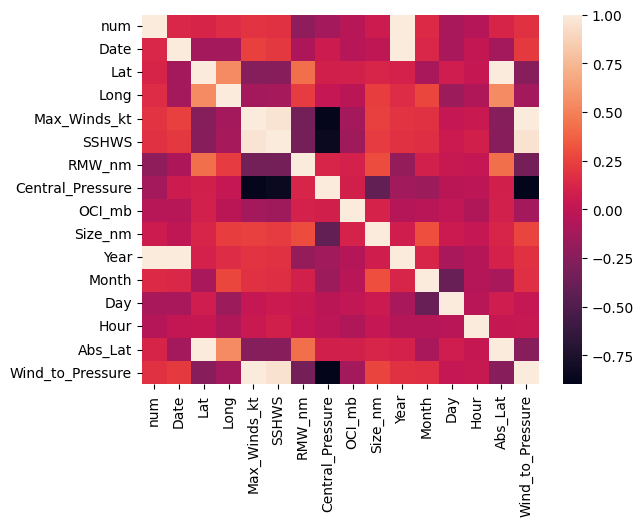

In [33]:
sns.heatmap(df.corr())
# Shows teh

In [39]:
 #  IQR filtering so make sure we are keeping values that are near the Q1 or Q3 or between

def remove_outliers (df, columns):
  for col_name in columns:
        Q1 = df[col_name].quantile(0.25)
        Q3 = df[col_name].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[col_name] >= lower) & (df[col_name] <= upper)]

  return df

In [42]:
df_new=remove_outliers(df,df.columns)
df_new.head()

,num,Date,Lat,Long,Max_Winds_kt,SSHWS,RMW_nm,Central_Pressure,OCI_mb,Size_nm,Year,Month,Day,Hour,Abs_Lat,Wind_to_Pressure
2,3,1901-08-15,30.4,-88.8,75,1,35.0,973.0,1010,300,1901.0,8.0,15.0,17,30.4,0.077081
3,4,1903-09-11,26.1,-80.1,75,1,45.0,976.0,1013,150,1903.0,9.0,11.0,23,26.1,0.076844
9,10,1906-06-17,25.2,-80.7,75,1,25.0,979.0,1012,300,1906.0,6.0,17.0,8,25.2,0.076609
10,11,1906-09-17,33.3,-79.2,80,1,30.0,977.0,1014,175,1906.0,9.0,17.0,22,33.3,0.081883
11,12,1906-09-27,30.2,-88.6,95,2,45.0,958.0,1009,250,1906.0,9.0,27.0,11,30.2,0.099165


In [43]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler
scaler=MinMaxScaler() # we are about to scale all the values to be within 0-1 range


In [49]:
x = df.drop(['Size_nm', "Date"], axis=1)
y = df['Size_nm']

In [65]:
x=scaler.fit_transform(x)
x
y = scaler.fit_transform(y.values.reshape(-1, 1))
x_train=np.array(x)
y_train=np.array(y)
mask = ~np.isnan(x_train).any(axis=1)
x_train = x_train[mask]
y_train = y_train[mask]
print(np.isnan(x_train).sum())
print(np.isnan(y_train).sum())

0
0


In [66]:
x_train,x_test,y_train,y_test=train_test_split(x_train,y_train,random_state=42,test_size=0.2)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [87]:
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.losses import MeanSquaredError, MeanAbsoluteError, LogCosh
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU
# class myCallback(tf.keras.callbacks.Callback):
#   def on_epoch_end(self, epoch, logs={}):
#       if(logs.get('mae')>0.99):
#         print("\nReached 99% accuracy so cancelling training!")
#         self.model.stop_training = True


# callbacks = myCallback()
model=Sequential([
    Dense(64, input_dim=x_train.shape[1]),
    LeakyReLU(0.1),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
]

)
opt=Adam(learning_rate=0.001)
model.compile(loss = LogCosh() , optimizer = opt , metrics = ['mae'])
history = model.fit(x_train , y_train , epochs = 300 , batch_size = 80, validation_split = 0.2)

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0644 - mae: 0.3111 - val_loss: 0.0716 - val_mae: 0.3305
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.0570 - mae: 0.2917 - val_loss: 0.0539 - val_mae: 0.2782
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0462 - mae: 0.2595 - val_loss: 0.0395 - val_mae: 0.2315
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0327 - mae: 0.2041 - val_loss: 0.0288 - val_mae: 0.1965
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.0248 - mae: 0.1713 - val_loss: 0.0216 - val_mae: 0.1674
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0260 - mae: 0.1854 - val_loss: 0.0175 - val_mae: 0.1450
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0231 - mae: 0.1699 - val_loss: 0.0159 - val_mae: 0.1364
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0260 - mae: 0.1756 - val_loss: 0.0157 - val_mae: 0.1360
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.0263 - mae: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


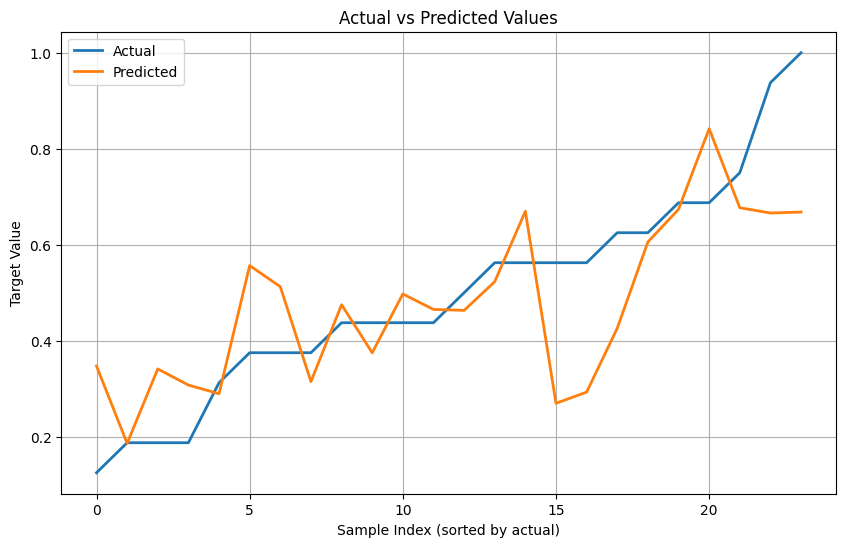

In [90]:
import matplotlib.pyplot as plt
import numpy as np


# Make predictions
y_pred = model.predict(x_test).flatten()
y_true = np.array(y_test).flatten()

# Sort by actual values (optional, just for easier visualization)
sorted_idx = np.argsort(y_true)
y_true_sorted = y_true[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

# Plot actual vs predicted
plt.figure(figsize=(10, 6))
plt.plot(y_true_sorted, label="Actual", linewidth=2)
plt.plot(y_pred_sorted, label="Predicted", linewidth=2)
plt.title("Actual vs Predicted Values")
plt.xlabel("Sample Index (sorted by actual)")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.show()



In [91]:
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_41 (Dense)                │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,221 (36.02 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,148 (24.02 KB)

In [92]:
import joblib
joblib.dump(model, 'hurricane_model.joblib')

['hurricane_model.joblib']